In [13]:
import numpy as np
import xarray as xr
import sys
sys.path.append("/n/home02/pbb/scripts/halo-metadata-server/")
# from Classes import Trajectory, Project
from matplotlib import pyplot as plt
import rioxarray as rioxr
from rasterio.enums import Resampling
from pathlib import Path
import time
import pandas as pd
import seaborn as sns


# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
# plt.rcParams.update({'font.size': 11})
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.3, style="ticks", rc=custom_params)

# Output metric directory
metricdir = Path('/n/davies_lab/Lab/shared_projects/ThermalLandscapes/data/out')
figdir = Path('/n/home02/pbb/scripts/halo-metadata-server/ThermalLandscapes/figs/SensitivityAnalysis')

# Loop through and run image sensitivity analyses

In [3]:
# directory to read in image statistics from chosen images at each site
statdir = Path('../data/out/')

figdir = Path(f'{figdir}/final_120722/AllSites')

# Site strings to loop thru
# NOTE: stupidly- there are 2 naming conventions here
# we fix this in the below loop
# for now, _tl = thermal landscapes names
# and _it = image traj names
sites = ['BuffaloCamp', 'Hlangwine', 'Letaba',
         'Makhohlola', 'Nkuhlu', 'RoanCamp']
sites_it = ['BuffaloCamp100m', 'HlangwineEP', 'LetabaExclosure',
          'MakhohlolaEP', 'NkuluEP', 'RoanCamp']

# Buffalo camp for testing
# sites = ['BuffaloCamp']

# sites_it = ['BuffaloCamp100m']

# This is the air temp that FLIR used to calculate temperature in the images
# likewise, the other parameters below are the FLIR camera parameters
# (or our best guess at them) for converting signal -> temp
default_airtemp = 22

# Plotting options
exclosure_hues=["Outside", "Inside"]

# Make a range of emissivity values to loop through
# etarget_range = np.arange(0.85, 1, 0.01)
etarget_range = [0.85, 1.0]

In [4]:
# Define Functions

# Function for calculating temp from signal (note in kelvin)
def tempcalc(signal, R=366545, B=1428, F=1, O=342):
    temp = (B / np.log((R / (signal - O)) + F))
    return temp

# Calculating signal (phi or energy)
# note temp is in kelvin
def phicalc(temp_kelvin, R=366545, B=1428, F=1, O=342):
    phi = (R / (np.exp(B / temp_kelvin) - F)) + O
    return phi

# # Calculating Tau (transmissivity of air)
# MJ - "Note that some of these atmos. Constants may be different for your camera"
# Note: Temp in C
def taucalc(distance, airtemp, RH,
            ATA1=0.006569,
            ATA2=0.01262,
            ATB1=0.002276,
            ATB2=0.00667,
            ATX=1.9):
    ch2o = ((RH/100) * np.exp((1.5587 + 0.06939*(airtemp)) - (0.00027816*(airtemp)**2) + (0.00000068455*(airtemp)**3)))
    tau = ATX * np.exp(-np.sqrt(distance) * (ATA1 + ATB1 * np.sqrt(ch2o))) + (1 - ATX) * np.exp(-np.sqrt(distance) * (ATA2 + ATB2*np.sqrt(ch2o)))
    # if np.isfinite(tau):
    #     tau = 1
    # if not np.isnan(tau):
    #     tau = 1
    return tau

# # Make an air signal (air energy) raster
def airsignalcalc(airtau, airtemp_kelvin):
    # Calc phi (energy)of air at given temp
    airphi = phicalc(airtemp_kelvin)
    # Tau of window (assuming 100% transmissivity thru the window)
    tauwin = 1
    # Calc airsignal
    airsignal = airphi * (1 - airtau) / tauwin
    return airsignal


def calcTargetTemp(phitotal, 
                   etarget,
                   phiair,
                   tauair=1, esky=1,
                   phiwin=1, reflwin=1,
                   tauwin=1):
    
    # p = (phitotal / (etarget*tauair*tauwin)) -
    #     ((phisky * esky * (1 - etarget)) / etarget) -
    #     ((phiair * (1 - tauair))/(etarget * tauair)) -
    #     ((phiwin * (1 - reflwin - tauwin)) / (etarget * tauair * tauwin))
    
    # phisky,
    # phiair,
    # phiwin=1, reflwin=1, tauwin=1
    # Simplified version (excludes the reflection, air, and window terms
    # total energy given emissivity - total energy contributed by air (0 if tauair=1)
    # p = (phitotal / (etarget*tauair*tauwin)) - ((phiair * (1 - tauair))/(etarget * tauair)) 
    
    # Updated 1/28/24 - This version adds in the refl. term (sky term)
    p = (phitotal / (etarget*tauair*tauwin)) - ((phisky * esky * (1 - etarget)) / etarget) - ((phiair * (1 - tauair))/(etarget * tauair)) 
    
    # convert to temp
    t = tempcalc(p)
        
    return t


from scipy.stats import ttest_ind

def EffectSize_by_Exclosure(df, var='Temperature', seed=None):

    # set random number seed
    if not seed:
        seed = 42
        
    # Split by Inside and Outside
    df_in = df.loc[df.Exclosure=='Inside']
    df_out = df.loc[df.Exclosure=='Outside']
    
    # Get sample size (number of pixels)
    n_in = len(df_in[var])
    n_out = len(df_out[var])
    
    # Find the smaller area
    # and set the number of pixels to sample 
    # to be ~66% of the number of pixels in the smallest area
    numpix = int(np.floor(0.66*np.min([n_in, n_out])))
            
    # Sample pixels to account for spatial autocorrelation
    # Added a random number seed here so that results are reproducible 1/16
    df_in = df_in.sample(n=numpix, random_state=seed)
    df_out = df_out.sample(n=numpix, random_state=seed)
    
    # Run a welch's t-test (equal variances not assumed)
    t, p = ttest_ind(df_in[var],
                     df_out[var],
                     equal_var=False)
    
    # Also, run Cohen's D as a measure of effect size per image
    cd = cohen_d(df_in[var],
                 df_out[var])
    
    # Get sample size (number of pixels), and means
    n_in_final = len(df_in[var])
    n_out_final = len(df_out[var])
    
    mean_in = df_in[var].mean()
    mean_out = df_out[var].mean()
    meandiff = mean_in-mean_out
    
    std_in = df_in[var].std()
    std_out = df_out[var].std()
    stddiff = df_in[var].std() - df_out[var].std()
    
    CV_in =  df_in[var].std() / df_in[var].mean()
    CV_out = df_out[var].std() / df_out[var].mean()
    CVdiff = (df_in[var].std() / df_in[var].mean()) - (df_out[var].std() / df_out[var].mean())
    
    # Compile results
    results = (t, p, cd,
               meandiff, mean_in, mean_out,
               n_in_final, n_out_final,
               stddiff, std_in, std_out,
               CVdiff, CV_in, CV_out)
    
    return results

# Cohen's D - A Measure of effect size 
# aka: a measure of standardized mean difference
# mean1 - mean2 / pooled sample Std
# https://stackoverflow.com/questions/21532471/how-to-calculate-cohens-d-in-python/33002123#33002123
# Other useful links:
# http://ethen8181.github.io/machine-learning/ab_tests/causal_inference/matching.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
# https://en.wikipedia.org/wiki/Effect_size#Difference_family:_Effect_sizes_based_on_differences_between_means
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

def esresultstodf(ES_results, site):
    
    df_list = []
    
    for i in ES_results.iteritems():
        
        # Results Tuple is organized like:
        # (t, p, cd,
        #        meandiff, mean_in, mean_out,
        #        n_in_final, n_out_final,
        #        stddiff, std_in, std_out,
        #        CVdiff, CV_in, CV_out,)

        df = pd.DataFrame({'site':site,
                             'imgf': [i[0]],
                             'tstat':[i[1][0]],
                             'p':[i[1][1]],
                             'cohensd':[i[1][2]],
                             'meandiff':[i[1][3]],
                             'mean_inside':[i[1][4]],
                             'mean_outside':[i[1][5]],
                             'n_inside':[i[1][6]],
                             'n_outside':[i[1][7]],
                             'stddiff':[i[1][8]],
                             'std_inside':[i[1][9]],
                             'std_outside':[i[1][10]],
                             'CVdiff':[i[1][11]],
                             'CV_inside':[i[1][12]],
                             'CV_outside':[i[1][13]]})

        df_list.append(df)
    
    # Compile temperature statistics for this site
    # and save
    ESstats_s = pd.concat(df_list, ignore_index=True)
    
    return ESstats_s


# Assign emissivities to veg types,
# and see if it makes a difference
# Mainly using emissivity values from Griend and Owe, 1993, Table 2
# Also, this paper for more context
# https://www.researchgate.net/publication/341253627_Applications_of_UAV_Thermal_Imagery_in_Precision_Agriculture_State_of_the_Art_and_Future_Research_Outlook/figures?lo=1
def assign_emissivity(vegtype):
    
    e = 1.0 
    
    if ((vegtype == 'tree') |( vegtype == 'shrub')):
        e = 0.97 # from Griend and Owe 1993 - Table 2 - average of all shrub values
        
    elif vegtype == 'grass':
        e= 0.96 # from Griend and Owe 1993 - Table 2 - Long Grass
        
    elif vegtype == 'ground':
        e = 0.91 # from Griend and Owe 1993 - Table 2 - Bare Soil
        
    return e

# Also, calc the number and proportion of images with significant p-values and mean diff < 0
# Aka - proporation of images with significant differences that showed inside being cooler than outside
def calcpropimages(ES):
    trues = [((es.p <= 0.001) & (es.meandiff < 0)) for es in ES.itertuples()]
    ntrues = np.sum(trues)
    prop = ntrues / len(trues)
    return prop


In [ ]:
# # # LOOP Through Projects, Run Sensitivity Analyses
# First, make a new dataframe that combines:
# ONLY image files chosen for analysis from each site
# exact path to image files
# AirTemp and RH weather data

# for s, s_it in zip(sites, sites_it):
# Roan Camp seems to blow it up... why? I dunno
for s, s_it in zip([sites[-1]], [sites_it[-1]]):
    
    # # # Make a new pixel dataframe with weather data, everything you'd need for corrections
    # read in image trajectories
    imgtraj_df = pd.read_csv(f'../data/in/ImageTrajectories/{s_it}_ImageTrajectory_withWeather.csv')
    
    # read in image pickle file 
    pixel_df = pd.read_pickle(f'../data/out/pixelpickles/{s}_pixels.obj')
    
    # Pair down and clean image traj df
    # so that you can merge it with pixel_df
    imgtraj_df = imgtraj_df[['Imagef', 'Altitude', 'AirTemp', 'RH', 'DateTime']]
    
    # make an image file column for joining dfs 
    imgtraj_df['imgf'] = imgtraj_df.Imagef.apply(lambda i: i + '.tif')
    # drop column without a use
    imgtraj_df = imgtraj_df.drop('Imagef', axis=1)
    
    # now, make a new pixel_df that's got weather data in it
    pixel_df = pixel_df.merge(imgtraj_df)
    
    # Cool- you can even make a 'distance' column by subtracting elevation and altitude
    # Note: added a line here to fix distance calculation... cause it comes up negative for RoanCamp
    pixel_df['Distance'] = [a - e if ((a-e)>0) else 100.0 for a, e in zip(pixel_df['Altitude'], pixel_df['Elevation'])]
    
    # awesome! That's your pixel dataframe with everything you need to convert temp -> energy -> temp
    # and test sensitivity.
    
    # Save out for future reference
    pixel_df.to_pickle(f'{metricdir}/pixelpickles_weather/{s}_pixels_weather.obj')
    
    # # # Convert temp -> signal -> temp
    # Create a signal (phi) column
    pixel_df['phi'] = pixel_df.Temperature.apply(lambda t: phicalc(temp_kelvin = t + 273.15))

    # Create a tau (air transmissivity) column
    pixel_df['tau'] = pixel_df.apply(lambda x: taucalc(distance = x['Distance'],
                                                       airtemp = x['AirTemp'],
                                                       RH = x['RH']/100),
                                     axis=1)

    # # # loop through range of emissivities,
    # and make new temperature columns
    for et in etarget_range:

        # NOTE: maybe we should use a different airtemp here
        # (like the actual air temp that the picture was taken at)..
        # This would only make a difference if we used Tau air

        # Also, try a run with different emissivity values for each pixel based on their classification
        pixel_df[f'Temperature_e{int(et*100)}'] = pixel_df.apply(lambda x: calcTargetTemp(phitotal=x['phi'],
                                                                                          etarget=et,
                                                                                          phiair=airsignalcalc(airtemp_kelvin=default_airtemp + 273.15,
                                                                                                               airtau=x['tau']),
                                                                                          tauair=x['tau']) - 273.15,
                                                                 axis=1)
        
    # Also, assign emissivities to veg types (using function defined above)
    pixel_df['eVeg'] = pixel_df.VegType.apply(lambda v: assign_emissivity(v))
    
    
    # # # Compute Emissivity by vegtype
    pixel_df[f'Temperature_eVeg'] = pixel_df.apply(lambda x: calcTargetTemp(phitotal=x['phi'],
                                                                            etarget=x['eVeg'],
                                                                            phiair=airsignalcalc(airtemp_kelvin=default_airtemp + 273.15,
                                                                                                 airtau=x['tau']),
                                                                            tauair=x['tau']) - 273.15,
                                                   axis=1)
    
    
    print('now saving pixel df...\n')
    
    # save out pixel df
    pixel_df.to_pickle(f'{metricdir}/pixelpickles_sensitivity/{s}_pixelpickles_sensitivity.obj')
    
    # # # Plot and save figure
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
    sns.kdeplot(data=pixel_df, x='Temperature_e100', ax=ax1, hue='Exclosure',
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                legend=True,
                common_norm=False)
    
    sns.kdeplot(data=pixel_df, x='Temperature_e85', ax=ax2, hue='Exclosure',
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                legend=True,
                common_norm=False)
    
    sns.kdeplot(data=pixel_df, x='Temperature_eVeg', ax=ax3, hue='Exclosure',
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues,
                legend=True,
                common_norm=False)
    
    fig.tight_layout()
    fig.savefig(f'{figdir}/KDEPlot_SensitivityTests_{s}.png', dpi=300)
    
    
    # # # Make effect size and ttest statistic files by image and summarized for each site
    statsbyImg = pixel_df.groupby(['imgf'])
    
    # # Ttest and cohens d for temperature
    results_eVeg = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_eVeg'))
    results_e100 = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_e100'))
    results_e85 = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_e85'))
    results = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature'))
    results_pai = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='PAI'))
    results_height = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Height'))
    
    # Use custom function to convert to a df
    pai_df = esresultstodf(results_pai, site=s)
    height_df = esresultstodf(results_height, site=s)
    eVeg_df = esresultstodf(results_eVeg, site=s)
    flir_df = esresultstodf(results, site=s)
    e85_df = esresultstodf(results_e85, site=s)
    e100_df = esresultstodf(results_e100, site=s)
    
    print('now saving sensitivity pixel metrics...\n')
    
    # Save these out
    pai_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_paiES_sensitivity.obj')
    height_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_heightES_sensitivity.obj')
    eVeg_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_eVegES_sensitivity.obj')
    flir_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_flirES_sensitivity.obj')
    e85_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e85ES_sensitivity.obj')
    e100_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e100ES_sensitivity.obj')
    
    # Combine cd results and save
    df_tempcd = pd.DataFrame({'pai':pai_df.cohensd,
                              'height':height_df.cohensd,
                              'eVeg':eVeg_df.cohensd,
                              'e100':e100_df.cohensd,
                              'e85':e85_df.cohensd,
                              'FLIR':flir_df.cohensd})

    # save out pixel df
    df_tempcd.to_csv(f'{metricdir}/pixelpickles_sensitivity/{s}_TempCohensD_SensitivityAnalysis.csv')

    # Also, save another df of pvalues...
    df_p = pd.DataFrame({'pai':pai_df.p,
                          'height':height_df.p, 
                          'eVeg':eVeg_df.p,
                          'e100':e100_df.p,
                          'e85':e85_df.p,
                          'FLIR':flir_df.p})
    
    # save out pixel df
    df_p.to_csv(f'{metricdir}/pixelpickles_sensitivity/{s}_TempPValue_SensitivityAnalysis.csv')

In [ ]:
# save out pixel df
# pixel_df.to_pickle(f'{metricdir}/pixelpickles_sensitivity/{s}_pixelpickles_sensitivity.obj')

# # # # Plot and save figure
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
# sns.kdeplot(data=pixel_df, x='Temperature_e100', ax=ax1, hue='Exclosure',
#             palette='plasma_r',
#             fill=True,
#             hue_order=exclosure_hues,
#             legend=True,
#             common_norm=False)

# sns.kdeplot(data=pixel_df, x='Temperature_e85', ax=ax2, hue='Exclosure',
#             palette='plasma_r',
#             fill=True,
#             hue_order=exclosure_hues,
#             legend=True,
#             common_norm=False)

# sns.kdeplot(data=pixel_df, x='Temperature_eVeg', ax=ax3, hue='Exclosure',
#             palette='plasma_r',
#             fill=True,
#             hue_order=exclosure_hues,
#             legend=True,
#             common_norm=False)

# fig.tight_layout()
# fig.savefig(f'{figdir}/KDEPlot_SensitivityTests_{s}.png', dpi=300)


# # # # Make effect size and ttest statistic files by image and summarized for each site
# statsbyImg = pixel_df.groupby(['imgf'])

# # # Ttest and cohens d for temperature
# results_eVeg = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_eVeg'))
# results_e100 = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_e100'))
# results_e85 = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_e85'))
# results = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature'))
# results_pai = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='PAI'))
# results_height = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Height'))

# # Use custom function to convert to a df
# pai_df = esresultstodf(results_pai, site=s)
# height_df = esresultstodf(results_height, site=s)
# eVeg_df = esresultstodf(results_eVeg, site=s)
# flir_df = esresultstodf(results, site=s)
# e85_df = esresultstodf(results_e85, site=s)
# e100_df = esresultstodf(results_e100, site=s)

# print('now saving sensitivity pixel metrics...\n')

# # Save these out
# # pai_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_paiES_sensitivity.obj')
# # height_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_heightES_sensitivity.obj')
# # eVeg_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_eVegES_sensitivity.obj')
# # flir_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_flirES_sensitivity.obj')
# # e85_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e85ES_sensitivity.obj')
# # e100_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e100ES_sensitivity.obj')

# # Combine cd results and save
# df_tempcd = pd.DataFrame({'pai':pai_df.cohensd,
#                           'height':height_df.cohensd,
#                           'eVeg':eVeg_df.cohensd,
#                           'e100':e100_df.cohensd,
#                           'e85':e85_df.cohensd,
#                           'FLIR':flir_df.cohensd})

# # save out pixel df
# df_tempcd.to_csv(f'{metricdir}/pixelpickles_sensitivity/{s}_TempCohensD_SensitivityAnalysis.csv')

# # Also, save another df of pvalues...
# df_p = pd.DataFrame({'pai':pai_df.p,
#                       'height':height_df.p, 
#                       'eVeg':eVeg_df.p,
#                       'e100':e100_df.p,
#                       'e85':e85_df.p,
#                       'FLIR':flir_df.p})

# # save out pixel df
# df_p.to_csv(f'{metricdir}/pixelpickles_sensitivity/{s}_TempPValue_SensitivityAnalysis.csv')

In [ ]:
# # Save these out
# pai_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_paiES_sensitivity.obj')
# height_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_heightES_sensitivity.obj')
# eVeg_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_eVegES_sensitivity.obj')
# flir_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_flirES_sensitivity.obj')
# e85_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e85ES_sensitivity.obj')
# e100_df.to_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e100ES_sensitivity.obj')

In [ ]:
# # # For testing: 

# # load buffalo camp
# s = 'BuffaloCamp'
# pixel_df = pd.read_pickle(f'../data/out/pixelpickles_sensitivity/{s}_pixelpickles_sensitivity.obj')

# # # # Make effect size and ttest statistic files by image and summarized for each site
# statsbyImg = pixel_df.groupby(['imgf'])

# # # Ttest and cohens d for temperature
# results_eVeg = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_eVeg'))
# results_e100 = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_e100'))
# results_e85 = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature_e85'))
# results = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Temperature'))
# results_pai = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='PAI'))
# results_height = statsbyImg.apply(lambda x: EffectSize_by_Exclosure(x, var='Height'))

# # Use custom function to convert to a df
# pai_df = esresultstodf(results_pai, site=s)
# eVeg_df = esresultstodf(results_eVeg, site=s)
# flir_df = esresultstodf(results, site=s)
# e85_df = esresultstodf(results_e85, site=s)
# e100_df = esresultstodf(results_e100, site=s)

In [ ]:
# ALso, save out proportion stats file 
# eVeg_df_g = eVeg_df.groupby('site')
# eVeg_propimg = eVeg_df_g.apply(lambda x: calcpropimages(x))
# eVeg_propimg

# flir_df_g = flir_df.groupby('site')
# flir_propimg = flir_df_g.apply(lambda x: calcpropimages(x))
# flir_propimg

# propimg_summary.to_csv(f'./stats/PropImageswithSigDiffinTemperature_AllSites.csv')

In [ ]:
# fig, ax = plt.subplots()

# pixel_df.Temperature_e100.hist(ax=ax, label='100% Emissivity')
# pixel_df.Temperature_e85.hist(ax=ax, label='85% Emissivity')
# fig.legend()

In [8]:
# Combine everything into one file....

eVeg_df_list = []
pai_df_list = []
flir_df_list = []
e85_df_list = []
e100_df_list = []

for s in sites:
    
    eVeg_df_list.append(pd.read_pickle(f'{metricdir}/ESstats_sensitivity/{s}_eVegES_sensitivity.obj'))
    pai_df_list.append(pd.read_pickle(f'{metricdir}/ESstats_sensitivity/{s}_paiES_sensitivity.obj'))
    flir_df_list.append(pd.read_pickle(f'{metricdir}/ESstats_sensitivity/{s}_flirES_sensitivity.obj'))
    e85_df_list.append(pd.read_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e85ES_sensitivity.obj'))
    e100_df_list.append(pd.read_pickle(f'{metricdir}/ESstats_sensitivity/{s}_e100ES_sensitivity.obj'))
    
# Compile ES temperature statistics from all sites
eVeg_df = pd.concat(eVeg_df_list, ignore_index=True)
pai_df = pd.concat(pai_df_list, ignore_index=True)
flir_df = pd.concat(flir_df_list, ignore_index=True)
e85_df = pd.concat(e85_df_list, ignore_index=True)
e100_df = pd.concat(e100_df_list, ignore_index=True) 

In [9]:
# make a combined dataframe that's easier to plot
eVeg_df['Method'] = np.repeat('Vegetation Emissivity', eVeg_df.shape[0])
eVeg_df['pai_cd'] = pai_df['cohensd']
flir_df['Method'] = np.repeat('Raw Camera Values', flir_df.shape[0])
flir_df['pai_cd'] = pai_df['cohensd']
temp_df = pd.concat([eVeg_df, flir_df])
# Add a pai column as well


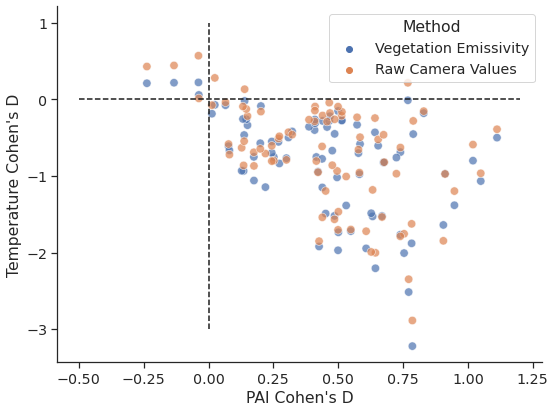

In [10]:
# Make plot of PAI vs cohens d (below)
plt.rcParams['figure.figsize'] = [8, 6]
fig, ax = plt.subplots()
# ax.scatter(x=pai_df.cohensd, y= eVeg_df.cohensd, label='eVeg', alpha=0.7, s=70)
# ax.scatter(x=pai_df.cohensd, y= flir_df.cohensd, label='FLIR', alpha=0.7, s=70)
# ax.scatter(x=pai_df.cohensd, y= e85_df.cohensd, label='e85', alpha=0.7)
# ax.scatter(x=pai_df.cohensd, y= e85_df.cohensd, label='e100', alpha=0.7)

sns.scatterplot(data = temp_df,
                x='pai_cd',
                y='cohensd',
                hue='Method',
                ax=ax,
                s=70,
                alpha=0.7,
                legend=True)
            
ax.vlines(0, -3, 1, 'k', '--')
ax.hlines(0, -0.5, 1.2, 'k', '--')
ax.set_xlabel('PAI Cohen\'s D')
ax.set_ylabel('Temperature Cohen\'s D')
# fig.legend()
fig.tight_layout()

fig.savefig(f'{figdir}/Scatter_SensitivityPAIxTemp_AllSites.png', dpi=300)

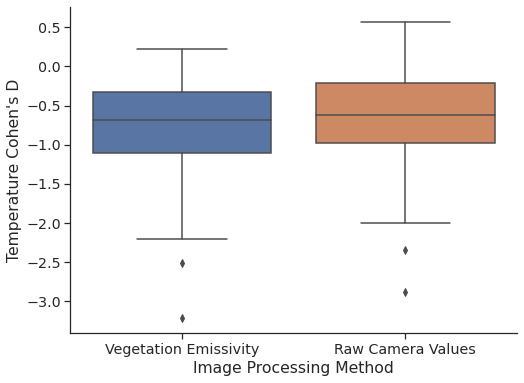

In [11]:
# Make plot of PAI vs cohens d (below)
plt.rcParams['figure.figsize'] = [8, 6]

fig, ax = plt.subplots()

sns.boxplot(data=temp_df, y='cohensd', x='Method', ax=ax)

# ax.scatter(x=pai_df.cohensd, y= e85_df.cohensd, label='e85', alpha=0.7)
# ax.scatter(x=pai_df.cohensd, y= e85_df.cohensd, label='e100', alpha=0.7)

# ax.vlines(0, -3, 1, 'k', '--')
# ax.hlines(0, -0.5, 1.2, 'k', '--')
ax.set_xlabel('Image Processing Method')
ax.set_ylabel('Temperature Cohen\'s D')
# fig.legend()
# fig.tight_layout()

fig.savefig(f'{figdir}/Boxplot_SensitivityTempCD_AllSites.png', dpi=300)

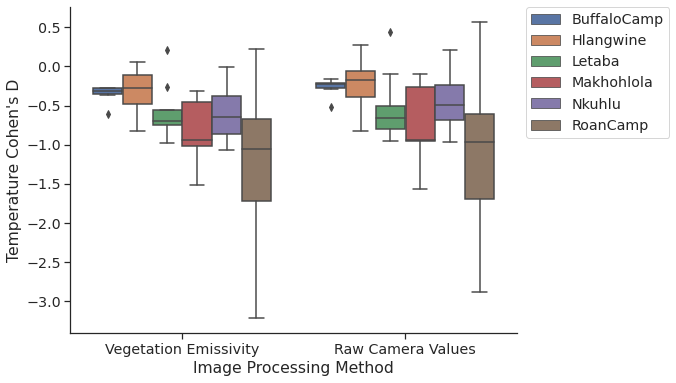

In [12]:
# Make plot of PAI vs cohens d (below)
plt.rcParams['figure.figsize'] = [8, 6]

fig, ax = plt.subplots()

sns.boxplot(data=temp_df, y='cohensd', x='Method', hue='site', ax=ax)

# ax.scatter(x=pai_df.cohensd, y= e85_df.cohensd, label='e85', alpha=0.7)
# ax.scatter(x=pai_df.cohensd, y= e85_df.cohensd, label='e100', alpha=0.7)

# ax.vlines(0, -3, 1, 'k', '--')
# ax.hlines(0, -0.5, 1.2, 'k', '--')
ax.set_xlabel('Image Processing Method')
ax.set_ylabel('Temperature Cohen\'s D')
# fig.legend()
# fig.tight_layout()

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.savefig(f'{figdir}/Boxplot_SensitivityTempCDbySite_AllSites.png', dpi=300)

### Scraps and Notes

In [ ]:
# MIRIAM's NOTES
# From her R code 
#Calibation function
  #phitotal = energy measured be camera
  #phisky = sky temeprature, converted to energy units
  #phiair = air temperature, converted to energy units
  #phiwin = temperature of the window through which the camera looks, converted to energy unity 
            #[irrelevant when tauwin=1 and reflwin=0]
  #tauair = air transmissivity (0-1), calculated via calctau_RH function, above
  #tauwin = 1 [if your camera were looking through a window, this would be relevant]
  #esky = 1 [emissivity of things contributing to phisky, in your case we're assuming sky only]
  #etarget = emissivity of the target of interest - I'm not sure what this is for you
  #reflwin = 0 [if your camera were looking through a window, this would be relevant]
  
#   #The output of this function is TARGET temperature (C)
# calfun<-function(phitotal,phisky,phiwin, phiair,tauair,tauwin,esky,etarget,reflwin){
#   energy2temp(   (phitotal/(etarget*tauair*tauwin)) - 
#                    ((phisky*esky*(1-etarget))/etarget) -
#                    ((phiair *(1-tauair))/(etarget*tauair)) - 
#                    ((phiwin*(1-reflwin-tauwin))/(etarget*tauair*tauwin))
#   )
# }
   

In [ ]:
# NOTE: Something is wrong with tau air...
# ignore it for now.
# Note - I think i fixed it. 
# inputting RH into tau air calc as /100
# before, it was input as a percentage
# pixel_df.tau.hist()